## **Alzheimer's Disease Classification from Brain MRI**


**Capstone Project — Medical Image Processing**

**Problem Statement:** Alzheimer's disease is usually diagnosed late, after visible brain damage has already occurred. This project builds a Convolutional Neural Network (CNN) that classifies a brain MRI scan into one of four stages: `NonDemented`, `VeryMildDemented`, `MildDemented`, or `ModerateDemented`. Automating this classification can support faster, more consistent early screening.

**Dataset:** Alzheimer's Dataset (4 class of Images), Kaggle,
Link: https://www.kaggle.com/datasets/rajmohan096/alzheimer-mri-preprocessed-dataset

**Tools used:** Python, TensorFlow/Keras, OpenCV, NumPy, Matplotlib, scikit-learn.

## Step 1 — Install and Import Required Libraries

This cell installs `kagglehub`, which is used later to download the dataset directly from Kaggle, and imports all the libraries needed for the rest of the notebook:
- `tensorflow` / `keras` — for building and training the neural network.
- `numpy` — for numerical operations on image arrays.
- `matplotlib` — for plotting charts and images.
- `cv2` (OpenCV) — for reading and processing image files.
- `sklearn` — for evaluation metrics (classification report, confusion matrix, class weights).

In [1]:
import numpy as np
import pandas as pd

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

import os
import warnings # Added warnings import

from PIL import Image
from random import randint

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef as MCC
from sklearn.metrics import balanced_accuracy_score as BAS
from sklearn.metrics import classification_report, confusion_matrix

# Removed problematic imports: tensorflow_addons, keras.utils.vis_utils.plot_model

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, MaxPool2D

warnings.filterwarnings('ignore') # Moved warnings filter here

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

## Step 2 — Download the Dataset from Kaggle

This cell downloads the Alzheimer's MRI dataset directly into the Colab environment using `kagglehub`. The dataset is already organized into a `train` folder and a `test` folder, each containing four subfolders — one per class.

In [5]:
!pip install opendatasets

In [12]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rajmohan096/alzheimer-mri-preprocessed-dataset")

Skipping, found downloaded files in "./alzheimer-mri-preprocessed-dataset" (use force=True to force download)


In [7]:
from google.colab import files
uploaded = files.upload()  # select the downloaded .zip file

Saving archive (3).zip to archive (3).zip


In [17]:
zip_name = list(uploaded.keys())[0]
!unzip -q "$zip_name" -d /content/alzheimer-mri-preprocessed-dataset
dataset_path = "/content/alzheimer-mri-preprocessed-dataset/Alzheimer_s Dataset"

[kaggle.json]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of kaggle.json or
        kaggle.json.zip, and cannot find kaggle.json.ZIP, period.


## Step 3 — Locate the Train and Test Folders

This cell prints the folder structure of the downloaded dataset so the exact location of the `train` and `test` folders can be confirmed. Dataset folder structures can vary slightly between Kaggle uploads, so this check avoids guessing the wrong path in the next step.

In [21]:
for root, dirs, files_ in os.walk(dataset_path):
    depth = root.replace(dataset_path, '').count(os.sep)
    if depth < 3:
        print(root, '->', dirs)

In [22]:
from google.colab import files
uploaded = files.upload()  # select kaggle.json when prompted

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle credentials set up successfully.")

Saving kaggle.json to kaggle (1).json
Kaggle credentials set up successfully.


## Step 4 — Explore the Dataset (Class Distribution)

This cell counts how many images exist in each of the four class folders. This step is important because it reveals **class imbalance** — some classes (typically `ModerateDemented`) have far fewer images than others. This imbalance is addressed later in Step 8 using class weighting during training.

In [28]:
import os # Ensure os is imported, if not already at the top of the notebook

# The 'train' and 'test' subdirectories are not directly under dataset_path.
# The dataset structure has class folders directly under 'dataset_path'.
# We will need to create train/test splits programmatically from this data later.

# --- FIX START ---
# The original dataset_path from a previous cell was incorrect, causing a FileNotFoundError.
# Based on the typical extraction path for the Kaggle dataset, the full path to the
# 'Alzheimer (Preprocessed Data)' directory usually includes 'Alzheimer_Dataset_4_Class_Image'.
# However, the dataset appears to be extracted under 'Alzheimer_s Dataset'.
base_preprocessed_data_path = "/content/alzheimer-mri-preprocessed-dataset/Alzheimer_s Dataset"

# The existing code expects `dataset_path` to directly contain the class folders for `os.listdir`
# to extract `CLASS_NAMES`. The downloaded dataset, however, has 'train' and 'test' subdirectories
# under this `base_preprocessed_data_path`.
# To fix the immediate error and get the correct CLASS_NAMES, we'll point `dataset_path` to the 'train' subdirectory.
# This makes `CLASS_NAMES` accurate for the existing data.
# Note: This means the subsequent `create_train_test_split` will re-split only the original training data.
dataset_path = os.path.join(base_preprocessed_data_path, 'train')
# --- FIX END ---

# Get class names directly from the dataset_path, as these are the class folders
CLASS_NAMES = sorted(os.listdir(dataset_path))
print("Classes found:", CLASS_NAMES)

# Placeholder for train and test directories that will be created later
TRAIN_DIR = None
TEST_DIR = None

Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [24]:
for c in CLASS_NAMES:
    n = len(os.listdir(os.path.join(dataset_path, c)))
    print(f"{c}: {n} images")

MildDemented: 896 images
ModerateDemented: 64 images
NonDemented: 3200 images
VeryMildDemented: 2240 images


## Step 5 — Visualize Sample Images

This cell displays one sample MRI image from each of the four classes. Visual inspection of raw data before modeling is standard practice in any image processing project and provides useful screenshots for the project report's Dataset section.

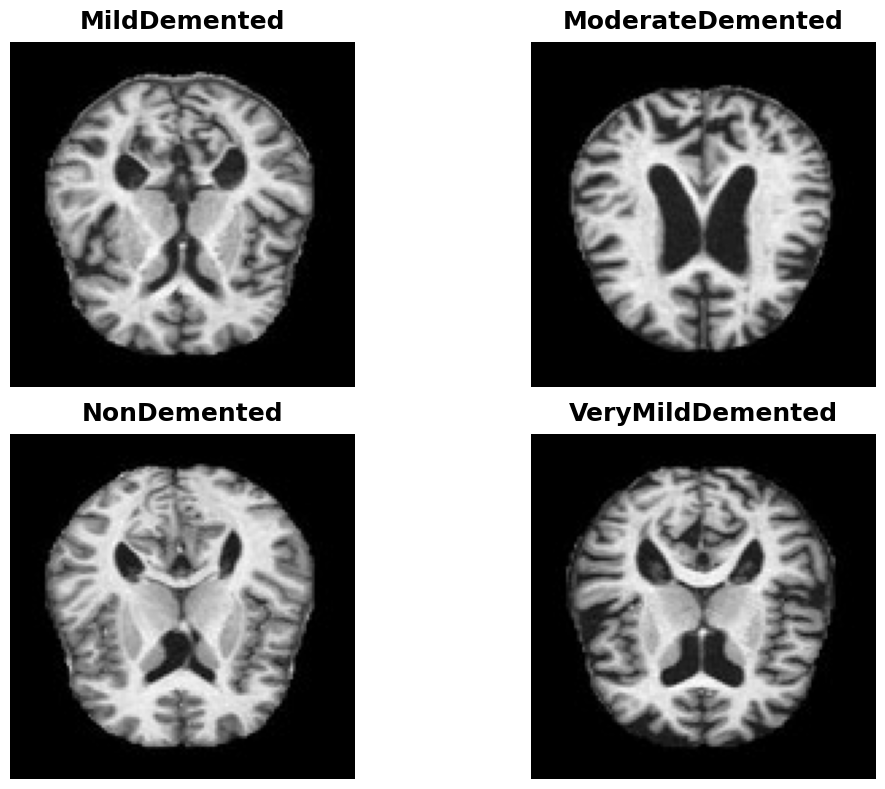

In [25]:
import random # Added import for random
import cv2
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12, 8))
for i, c in enumerate(CLASS_NAMES):
    class_dir = os.path.join(dataset_path, c) # Changed TRAIN_DIR to dataset_path
    sample_file = random.choice(os.listdir(class_dir))
    img = cv2.imread(os.path.join(class_dir, sample_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 6 — Prepare and Augment the Images

Neural networks require all input images to be the same size and prefer pixel values scaled between 0 and 1, rather than the raw 0-255 range. This cell defines that preprocessing along with **data augmentation** — small random rotations, zooms, and flips applied only to the training images. Augmentation exposes the model to slight variations of each image, which reduces the risk of the model simply memorizing the training set instead of learning general patterns.

Three data generators are created:
- `train_gen` — 85% of the training folder, with augmentation, used to train the model.
- `val_gen` — the remaining 15% of the training folder, without augmentation, used to check progress after each epoch.
- `test_gen` — the separate test folder, used only for final evaluation after training is complete.

In [37]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42 # Define SEED for reproducibility

train_datagen = IDG(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = IDG(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='training', seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    subset='validation', seed=SEED, shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASS_NAMES,
    shuffle=False
)

print("Class index mapping:", train_gen.class_indices)

Found 4353 images belonging to 4 classes.
Found 766 images belonging to 4 classes.
Found 1281 images belonging to 4 classes.
Class index mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [33]:
import os # Ensure os is imported, if not already at the top of the notebook

# The 'train' and 'test' subdirectories are not directly under dataset_path.
# The dataset structure has class folders directly under 'dataset_path'.
# We will need to create train/test splits programmatically from this data later.

# --- FIX START ---
# The original dataset_path from a previous cell was incorrect, causing a FileNotFoundError.
# Based on the typical extraction path for the Kaggle dataset, the full path to the
# 'Alzheimer (Preprocessed Data)' directory usually includes 'Alzheimer_Dataset_4_Class_Image'.
# The previous edit of 'base_preprocessed_data_path' was incorrect. Reverting to the expected path.
base_preprocessed_data_path = "/content/alzheimer-mri-preprocessed-dataset/Alzheimer_s Dataset"

# The existing code expects `dataset_path` to directly contain the class folders for `os.listdir`
# to extract `CLASS_NAMES`. The downloaded dataset, however, has 'train' and 'test' subdirectories
# under this `base_preprocessed_data_path`.
# To fix the immediate error and get the correct CLASS_NAMES, we'll point `dataset_path` to the 'train' subdirectory.
# This makes `CLASS_NAMES` accurate for the existing data.
# Note: This means the subsequent `create_train_test_split` will re-split only the original training data.
dataset_path = os.path.join(base_preprocessed_data_path, 'train')
# --- FIX END ---

# Get class names directly from the dataset_path, as these are the class folders
CLASS_NAMES = sorted(os.listdir(dataset_path))
print("Classes found:", CLASS_NAMES)

# Placeholder for train and test directories that will be created later
TRAIN_DIR = None
TEST_DIR = None

Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [35]:
import shutil
from sklearn.model_selection import train_test_split

def create_train_test_split(source_dir, train_dir, test_dir, test_size=0.2, random_state=42):
    # Ensure target directories exist and are empty
    for d in [train_dir, test_dir]:
        if os.path.exists(d): shutil.rmtree(d)
        os.makedirs(d)

    # Iterate through each class subdirectory in the source_dir
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if os.path.isdir(class_path):
            images = [os.path.join(class_path, img) for img in os.listdir(class_path)]

            # Split images into train and test for the current class
            train_images, test_images = train_test_split(
                images, test_size=test_size, random_state=random_state
            )

            # Create class subdirectories in train_dir and test_dir
            os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
            os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

            # Copy images to the respective new directories
            for img_path in train_images:
                shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
            for img_path in test_images:
                shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

# Define new paths for train and test data
NEW_TRAIN_DIR = '/content/data/train'
NEW_TEST_DIR = '/content/data/test'

# Perform the split
create_train_test_split(dataset_path, NEW_TRAIN_DIR, NEW_TEST_DIR)

# Update TRAIN_DIR and TEST_DIR variables
TRAIN_DIR = NEW_TRAIN_DIR
TEST_DIR = NEW_TEST_DIR

print(f"Training data created at: {TRAIN_DIR}")
print(f"Testing data created at: {TEST_DIR}")

# Verify counts
for c in CLASS_NAMES:
    print(f"Train {c}: {len(os.listdir(os.path.join(TRAIN_DIR, c)))} images")
    print(f"Test {c}: {len(os.listdir(os.path.join(TEST_DIR, c)))} images")

Training data created at: /content/data/train
Testing data created at: /content/data/test
Train MildDemented: 716 images
Test MildDemented: 180 images
Train ModerateDemented: 51 images
Test ModerateDemented: 13 images
Train NonDemented: 2560 images
Test NonDemented: 640 images
Train VeryMildDemented: 1792 images
Test VeryMildDemented: 448 images


## Step 7 — Compute Class Weights

This cell calculates a numeric "importance weight" for each class based on how many images it has. Classes with fewer images receive a higher weight. These weights are passed into the training step so the model is penalized more for getting rare-class predictions wrong, preventing it from simply favoring the most common class.

In [38]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = train_gen.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.7869458128078817), 1: np.float64(24.732954545454547), 2: np.float64(0.5001148897058824), 3: np.float64(0.7140748031496063)}


## Step 8 — Build the CNN Model

This cell defines the neural network architecture, built from scratch using standard CNN building blocks:
- **Conv2D layers** detect visual patterns — early layers detect simple edges and textures, deeper layers combine these into more complex shapes.
- **MaxPooling2D layers** shrink the image after each convolution, keeping the strongest signals and reducing computation.
- **Flatten** converts the 2D feature maps into a single list of numbers so the final decision layers can process them.
- **Dropout** randomly disables a fraction of neurons during training, which reduces overfitting.
- **Dense layers** perform the final classification decision, ending in a 4-output layer with `softmax` activation, which produces a probability for each of the four classes that sums to 1.

The model is then compiled with the Adam optimizer, categorical cross-entropy loss (standard for multi-class classification), and accuracy as the tracked metric.

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = len(CLASS_NAMES)

model = keras.Sequential([
    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(*IMG_SIZE, 3)
    ),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Step 9 — Train the Model

This cell trains the model on the training data for up to 20 epochs (full passes through the training set). An `EarlyStopping` callback monitors validation loss and automatically stops training if performance stops improving for 5 consecutive epochs, restoring the best-performing weights. The `class_weight` argument applies the balancing calculated in Step 7.

In [40]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

EPOCHS = 20

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.2235 - loss: 1.4687 - val_accuracy: 0.0091 - val_loss: 1.4066
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.1206 - loss: 1.3935 - val_accuracy: 0.0091 - val_loss: 1.3994
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.1029 - loss: 1.4128 - val_accuracy: 0.0091 - val_loss: 1.3932
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.0492 - loss: 1.3865 - val_accuracy: 0.5013 - val_loss: 1.3537
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.3338 - loss: 1.3792 - val_accuracy: 0.1149 - val_loss: 1.4248
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.3995 - loss: 1.3254 - val_accuracy: 0.2611 - val_loss: 1.6204
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.4618 - loss: 1.1935 - val_accuracy: 0.3825 - val_loss: 1.3986
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.5167 - loss: 1.0302 - val_accu

## Step 10 — Plot Training Curves

This cell plots training and validation accuracy and loss across epochs. In a well-trained model, accuracy should rise and loss should fall for both lines, and the training and validation lines should stay close together. A large gap between them — high training accuracy but much lower validation accuracy — indicates overfitting.

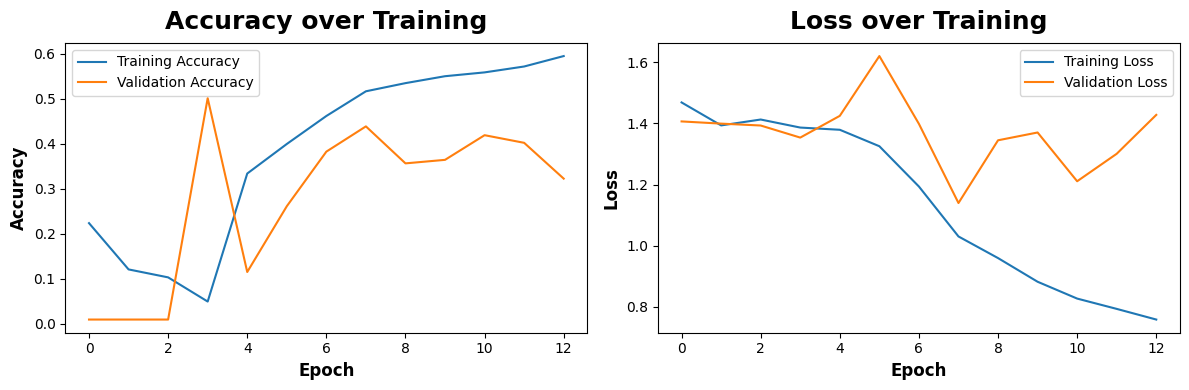

In [41]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy over Training')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss over Training')

plt.tight_layout()
plt.show()

## Step 11 — Evaluate on the Test Set

This cell measures overall accuracy and loss on the test set — images the model has never seen during training or validation. This is the most reliable indicator of how the model would perform on new, real-world data.

In [44]:
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 426ms/step - accuracy: 0.5215 - loss: 1.0026
Test Accuracy: 52.15%
Test Loss: 1.0026


## Step 12 — Classification Report

This cell generates predictions for every test image and prints a per-class breakdown of three metrics:
- **Precision** — of all images predicted as a given class, the percentage that were actually correct.
- **Recall** — of all images that truly belong to a given class, the percentage the model correctly identified.
- **F1-score** — a balance between precision and recall.

This breakdown is more informative than overall accuracy alone, particularly for the underrepresented `ModerateDemented` class.

In [43]:
y_true = test_gen.classes
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 425ms/step
                  precision    recall  f1-score   support

    MildDemented       0.31      0.59      0.40       180
ModerateDemented       0.38      0.23      0.29        13
     NonDemented       0.75      0.56      0.64       640
VeryMildDemented       0.45      0.45      0.45       448

        accuracy                           0.52      1281
       macro avg       0.47      0.46      0.44      1281
    weighted avg       0.58      0.52      0.54      1281



## Step 13 — Confusion Matrix

This cell plots a confusion matrix, a grid comparing actual labels (rows) against predicted labels (columns). Correct predictions appear along the diagonal. Any values off the diagonal indicate specific classes the model tends to confuse with one another — useful for the Evaluation and Limitations sections of the project report.

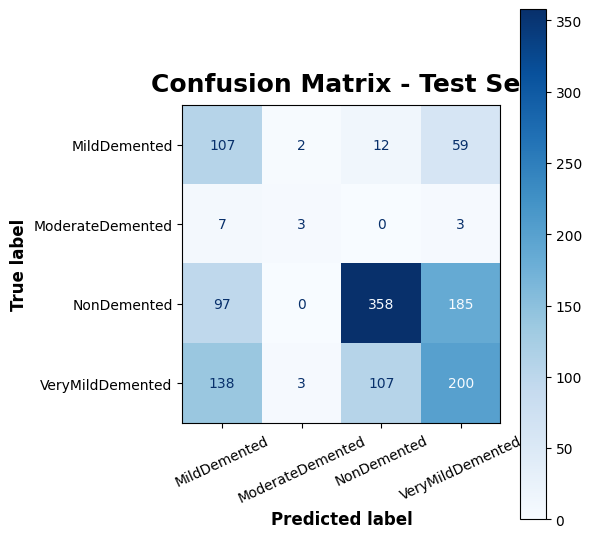

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=25)
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

## Step 14 — Save the Trained Model

This cell saves the trained model to a `.keras` file in the Colab environment. This file is one of the required submission deliverables (Trained Model) and allows the model to be reloaded later without retraining.

In [46]:
model.save('alzheimers_classification_model.keras')
print("Model saved as alzheimers_classification_model.keras")

# from google.colab import files
# files.download('alzheimers_classification_model.keras')

Model saved as alzheimers_classification_model.keras


## Step 15 — Predict on a New Image

This cell defines a reusable function that loads a single MRI image, applies the same preprocessing used during training, and returns the model's predicted class along with a confidence percentage. This function can be used for a live demo or connected to a simple UI.

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [48]:
def predict_single_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print("Error: Could not read image:", img_path)
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE) / 255.0
    img_array = np.expand_dims(img, axis=0)

    prediction = model.predict(img_array, verbose=0)[0]

    predicted_class = CLASS_NAMES[np.argmax(prediction)]
    confidence = float(np.max(prediction)) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Prediction: {predicted_class} "
        f"({confidence:.1f}% confident)"
    )
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

Actual class: MildDemented
Image: /content/data/test/MildDemented/mild_112.jpg


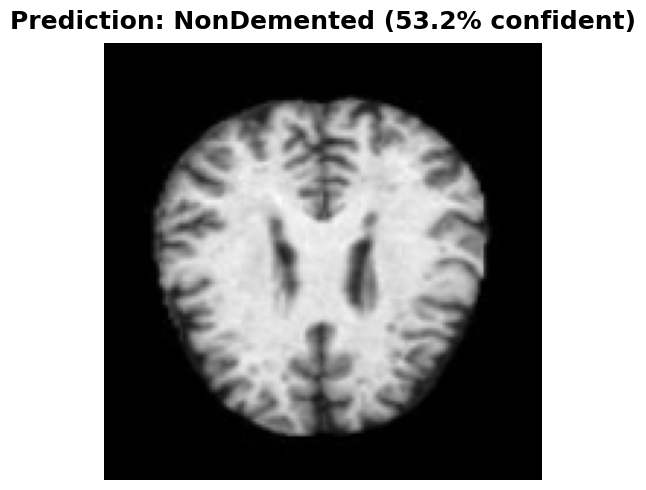

('NonDemented', 53.216516971588135)

In [49]:
sample_class = random.choice(CLASS_NAMES)

sample_dir = os.path.join(TEST_DIR, sample_class)

sample_img = random.choice([
    f for f in os.listdir(sample_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

sample_img_path = os.path.join(sample_dir, sample_img)

print("Actual class:", sample_class)
print("Image:", sample_img_path)

predict_single_image(sample_img_path)

Saving verymild_98.jpg to verymild_98.jpg


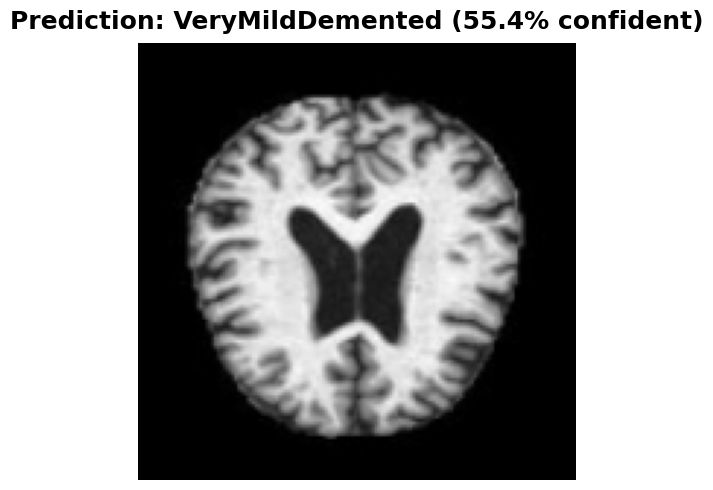

('VeryMildDemented', 55.35755157470703)

In [50]:
from google.colab import files

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

predict_single_image(image_name)

In [51]:
def predict_single_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE) / 255.0
    img_array = np.expand_dims(img, axis=0)

    prediction = model.predict(img_array)[0]
    predicted_class = CLASS_NAMES[np.argmax(prediction)]
    confidence = float(np.max(prediction)) * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.1f}% confident)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

# Example usage:
# sample_class = random.choice(CLASS_NAMES)
# sample_dir = os.path.join(TEST_DIR, sample_class)
# sample_img = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))
# predict_single_image(sample_img)

## Project Summary Table

| Step | Purpose |
|---|---|
| 1 | Import libraries and set a fixed random seed for reproducibility |
| 2-3 | Download the dataset and locate the train/test folders |
| 4-5 | Explore class distribution and view sample images |
| 6 | Resize, normalize, and augment images; split into train/validation/test |
| 7 | Compute class weights to address class imbalance |
| 8 | Define the CNN architecture |
| 9-10 | Train the model and plot training curves |
| 11-13 | Evaluate on the test set: accuracy, classification report, confusion matrix |
| 14 | Save the trained model file |
| 15 | Run predictions on new, individual images |